# Explainable Credit Risk Model with Automated Compliance Reason Codes

**Goal:** Build a credit default prediction model that is not only accurate but also *explainable* in the way real risk/compliance teams need — using SHAP for model-level interpretability, an LLM layer to translate SHAP outputs into plain-English, regulation-style adverse-action explanations (ECOA / Regulation B), and a portfolio-level Economic Capital extension that mirrors quantitative risk model validation work.

**Dataset:** [LendingClub](https://www.kaggle.com/datasets/wordsforthewise/lending-club) accepted loans, 2007–2018 — trimmed to **180,000 resolved loans** (`Fully Paid` or `Charged Off` only; loans still `Current`/`Late` are excluded because their final outcome isn't known yet and including them would be a label-leakage problem for a PD model).

**Why LendingClub over a purely anonymized scorecard dataset (e.g. Give Me Some Credit):** it has real loan-level `loan_amnt` (a genuine Exposure at Default) and post-default `recoveries` (from which a genuine Loss Given Default can be *computed*, not assumed). That turns Section 8's Economic Capital extension from "PD is real, EAD/LGD are illustrative" into something where every input is estimated from data — much closer to what a model validator actually reviews.

**Roadmap:**
1. Data understanding & cleaning
2. Feature selection via Information Value (IV) + WoE encoding
3. Handling class imbalance (SMOTE)
4. Model training & comparison (Logistic Regression, Random Forest, XGBoost)
5. Calibration & threshold selection
6. Portfolio Economic Capital (Vasicek Monte Carlo, VaR/ES, stress testing)
7. SHAP-based interpretability
8. LLM-generated compliance reason codes


## 1. Setup & Data Loading

In [60]:
!pip install -q scorecardpy imbalanced-learn xgboost shap

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

RANDOM_STATE = 42


In [62]:
df = pd.read_csv("lendingclub_trimmed.csv")
print(df.shape)
df.head()


(180000, 23)


,loan_amnt,funded_amnt,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,total_pymnt,recoveries,collection_recovery_fee
0,8000.0,8000.0,7.69,249.55,A,A4,1 year,MORTGAGE,80000.0,Not Verified,Fully Paid,debt_consolidation,8.73,0.0,1.0,11.0,0.0,7141.0,39.9,30.0,8367.070000,0.0,0.0
1,12000.0,12000.0,15.05,416.28,C,C4,< 1 year,OWN,36000.0,Verified,Fully Paid,debt_consolidation,17.86,0.0,1.0,7.0,0.0,4374.0,58.3,13.0,13928.386729,0.0,0.0
2,8000.0,8000.0,12.99,269.52,C,C1,2 years,RENT,26000.0,Source Verified,Fully Paid,debt_consolidation,27.98,1.0,0.0,11.0,1.0,4837.0,56.9,15.0,9637.025245,0.0,0.0
3,5000.0,5000.0,11.49,164.86,B,B5,NaN,OWN,28000.0,Verified,Fully Paid,other,12.69,0.0,0.0,5.0,0.0,11350.0,68.8,11.0,5928.419868,0.0,0.0
4,30800.0,30800.0,11.99,1022.86,C,C1,10+ years,MORTGAGE,150000.0,Verified,Fully Paid,credit_card,16.28,0.0,1.0,15.0,0.0,33661.0,53.9,34.0,36753.218139,0.0,0.0


**Data dictionary (post-trim, 23 raw columns):**

| Feature | Description |
|---|---|
| loan_status | Fully Paid / Charged Off (already filtered to resolved loans only) |
| loan_amnt | Loan amount funded — our real EAD source |
| funded_amnt | Amount actually funded (near-identical to loan_amnt; kept for a sanity check, dropped from modeling) |
| int_rate | Interest rate assigned at origination |
| installment | Monthly payment |
| annual_inc | Self-reported annual income |
| dti | Debt-to-income ratio |
| grade / sub_grade | LendingClub's own risk grade (A–G / A1–G5) — assigned at origination, safe to use as a predictor |
| emp_length | Employment length, categorical ("< 1 year" ... "10+ years") |
| home_ownership | RENT / OWN / MORTGAGE / OTHER / NONE / ANY |
| verification_status | Income verification status |
| purpose | Stated loan purpose |
| open_acc, total_acc | Open / total credit lines |
| revol_util, revol_bal | Revolving utilization % and balance |
| delinq_2yrs | Delinquencies in the last 2 years |
| inq_last_6mths | Credit inquiries in the last 6 months |
| pub_rec | Derogatory public records |
| recoveries, total_pymnt, collection_recovery_fee | **Post-outcome columns.** Only known *after* a loan has resolved — used exclusively for the Section 8 LGD calculation, never as PD model features (using them there would be leakage: predicting default using data that only exists because the loan already defaulted). |


## 2. Target Construction & Data Quality Checks

LendingClub dataset gives us `loan_status` as text. We construct the binary target first, then run the same cleaning discipline: check for missing values, implausible values, and structural issues — before touching any model.

In [63]:
df["default"] = (df["loan_status"] == "Charged Off").astype(int)
print(df["loan_status"].value_counts())
print()
print(df["default"].value_counts(normalize=True))


loan_status
Fully Paid     144266
Charged Off     35734
Name: count, dtype: int64

default
0    0.801478
1    0.198522
Name: proportion, dtype: float64


In [64]:
df.info()
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180000 entries, 0 to 179999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   loan_amnt                180000 non-null  float64
 1   funded_amnt              180000 non-null  float64
 2   int_rate                 180000 non-null  float64
 3   installment              180000 non-null  float64
 4   grade                    180000 non-null  object 
 5   sub_grade                180000 non-null  object 
 6   emp_length               169400 non-null  object 
 7   home_ownership           180000 non-null  object 
 8   annual_inc               180000 non-null  float64
 9   verification_status      180000 non-null  object 
 10  loan_status              180000 non-null  object 
 11  purpose                  180000 non-null  object 
 12  dti                      179952 non-null  float64
 13  delinq_2yrs              180000 non-null  float64
 14  inq_

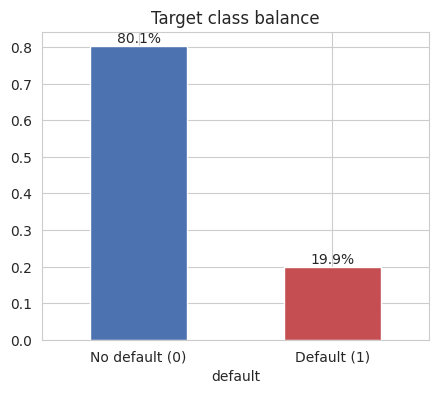

default
0    144266
1     35734
Name: count, dtype: int64


In [65]:
fig, ax = plt.subplots(figsize=(5,4))
df["default"].value_counts(normalize=True).plot(kind="bar", ax=ax, color=["#4C72B0","#C44E52"])
ax.set_title("Target class balance")
ax.set_xticklabels(["No default (0)","Default (1)"], rotation=0)
for i,v in enumerate(df["default"].value_counts(normalize=True)):
    ax.text(i, v+0.01, f"{v:.1%}", ha="center")
plt.show()
print(df["default"].value_counts())


Approximately **19.8%** of the resolved loans in the dataset were charged off. This is higher than the default rate typically reported for LendingClub's overall portfolio for two important reasons:

**Higher-risk borrower population.** LendingClub primarily issues unsecured consumer loans (often for debt consolidation), which naturally carry higher credit risk.
**Resolved-only sample**. To build a supervised learning model, each observation must have a known outcome. Therefore, only loans that had reached a final status (Fully Paid or Charged Off) were retained, while loans still marked as Current were excluded because their eventual outcome is unknown. Excluding these unresolved loans increases the observed charge-off proportion among the remaining data and should not be interpreted as the overall portfolio default rate.

The sample itself was obtained through a simple random draw from the 2007–2018 LendingClub dataset (without stratification), so the observed class distribution reflects the resolved-loan population rather than any sampling artifact.

As the target remains highly imbalanced, model performance will be evaluated using metrics such as **ROC-AUC, F1-score, and Recall** rather than accuracy alone. Class imbalance will be addressed during model training using **SMOTE**.

In [66]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,180000.0,14431.047222,8730.759182,500.00,8000.00000,12000.000000,20000.000000,4.000000e+04
funded_amnt,180000.0,14421.409722,8726.777141,500.00,8000.00000,12000.000000,20000.000000,4.000000e+04
int_rate,180000.0,13.244708,4.781085,5.31,9.75000,12.740000,15.990000,3.099000e+01
installment,180000.0,438.394029,261.477551,15.69,249.07000,374.370000,582.080000,1.719830e+03
annual_inc,180000.0,76099.353890,67507.474323,0.00,45600.00000,65000.000000,90000.000000,8.400000e+06
dti,179952.0,18.290327,11.367866,0.00,11.82000,17.640000,24.000000,9.990000e+02
delinq_2yrs,180000.0,0.315389,0.872774,0.00,0.00000,0.000000,0.000000,2.600000e+01
inq_last_6mths,180000.0,0.655789,0.938481,0.00,0.00000,0.000000,1.000000,8.000000e+00
open_acc,180000.0,11.585178,5.471937,0.00,8.00000,11.000000,14.000000,9.000000e+01
pub_rec,180000.0,0.214994,0.588790,0.00,0.00000,0.000000,0.000000,4.600000e+01


A few things to handle, LendingClub's own version of "real credit data is messy":

- **`emp_length`** is categorical text (`"< 1 year"` … `"10+ years"`) with ~5.9% missing — we'll ordinal-encode it for the tree-model path and let `scorecardpy` bin the missing category directly for WoE.
- **`dti`** and **`revol_util`** have a small number of missing values (48 and 118 rows respectively) — negligible relative to 180k rows, imputed with the median grouped by target class (keeps signal in the target-relevant subgroups).
- **`loan_amnt` vs `funded_amnt`** are near-duplicates (funded amount is almost always the full requested amount) — we keep `loan_amnt` and drop `funded_amnt` to avoid feeding the model two collinear versions of the same signal.

In [67]:
# Impute dti and revol_util with the median, grouped by default status
for col in ["dti", "revol_util"]:
    df[col] = df.groupby("default")[col].transform(lambda x: x.fillna(x.median()))

# emp_length: keep as categorical text for WoE; also build an ordinal version for the tree-model path
emp_length_map = {
    "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
    "5 years": 5, "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9, "10+ years": 10
}
df["emp_length_ord"] = df["emp_length"].map(emp_length_map)
df["emp_length_ord"] = df["emp_length_ord"].fillna(-1)  # -1 = unknown/missing, a tree can split on this meaningfully
df["emp_length"] = df["emp_length"].fillna("Unknown")   # scorecardpy bins this as its own category

print("Remaining missing values:\n", df.isnull().sum().sum())


Remaining missing values:
 0


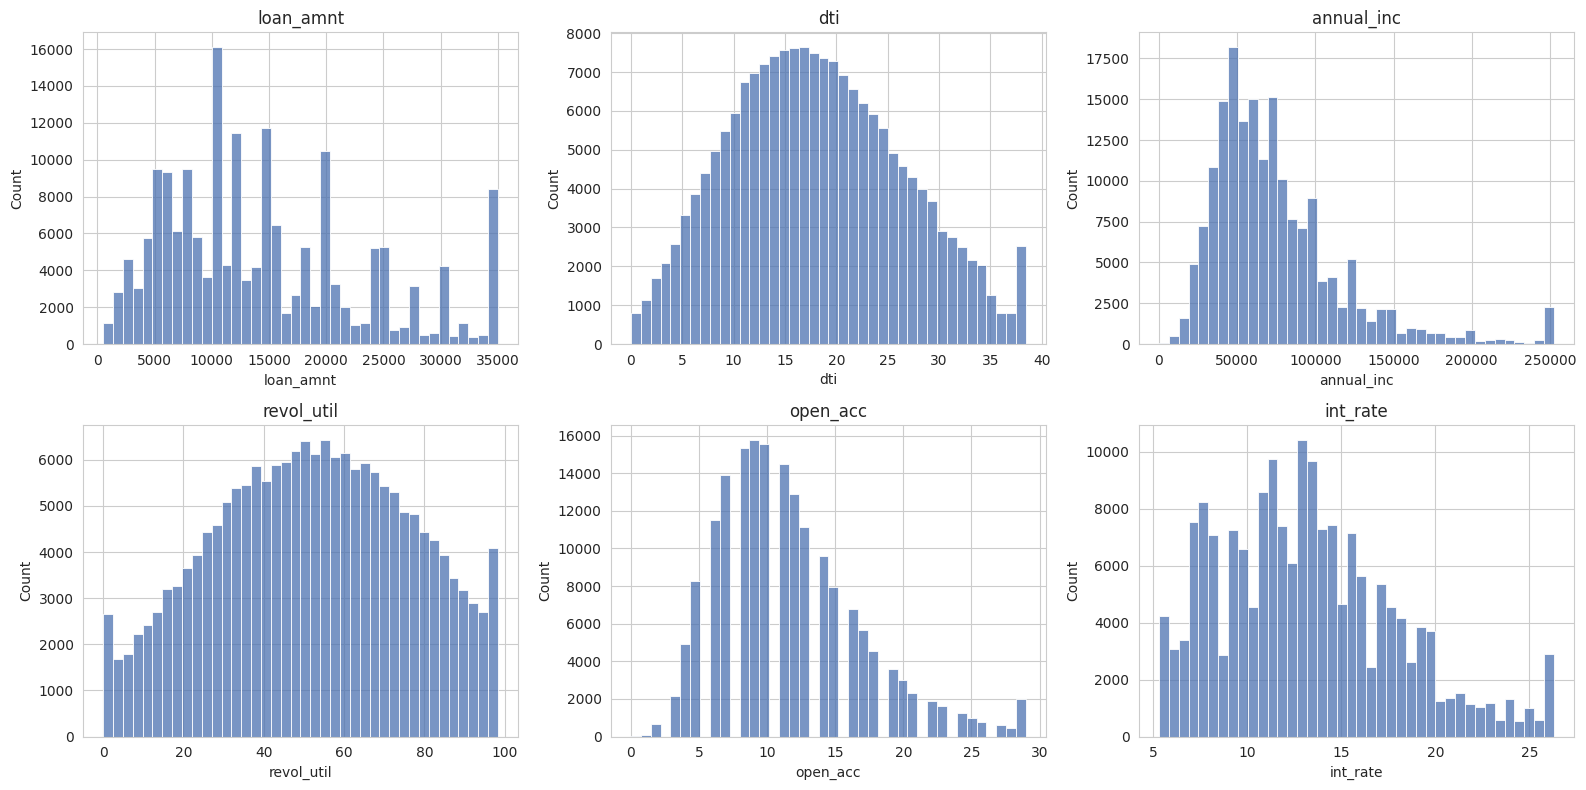

In [68]:
fig, axes = plt.subplots(2, 3, figsize=(16,8))
plot_cols = ["loan_amnt","dti","annual_inc","revol_util","open_acc","int_rate"]
for ax, col in zip(axes.flat, plot_cols):
    sns.histplot(df[col].clip(upper=df[col].quantile(0.99)), bins=40, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()


Now that the data is cleaned, we split into train/test **before** doing any further feature engineering — this avoids leaking test-set information into the WoE bins or feature selection step.

## 3. Train/Test Split

**Why split now, before WoE/IV?** WoE bin edges and IV scores are *statistics computed from the data* (bad/good rates per bin). If we compute them on the full dataset and only split afterward, the test set's own label statistics have quietly leaked into the feature encoding used to train the model — the model would then be evaluated on data it was indirectly shown. This is a subtle but real methodological error, and exactly the kind of thing a model validator is trained to catch. We split first, and every downstream step (WoE fitting, SMOTE, scaling) uses **train-only statistics**, applied *to* the test set without ever being *fit on* it.

In [69]:
from sklearn.model_selection import train_test_split

# Columns available for the PD model: everything except identifiers, the raw target text,
# and the post-outcome columns reserved for Section 8's LGD calculation.
leakage_cols = ["recoveries", "total_pymnt", "collection_recovery_fee"]
drop_cols = ["loan_status", "funded_amnt"] + leakage_cols

model_cols = [c for c in df.columns if c not in drop_cols]
df_model = df[model_cols].copy()

train_df, test_df = train_test_split(
    df_model, test_size=0.2, random_state=RANDOM_STATE, stratify=df_model["default"]
)
print("Train shape:", train_df.shape, " Test shape:", test_df.shape)
print("Train class balance:\n", train_df["default"].value_counts(normalize=True))


Train shape: (144000, 20)  Test shape: (36000, 20)
Train class balance:
 default
0    0.801479
1    0.198521
Name: proportion, dtype: float64


## 4. Feature Selection with Information Value (IV) & WoE Encoding (fit on train only)

**Why IV/WoE and not just feature importance from a tree model?** IV is the industry-standard way credit risk teams pre-screen features *before* modeling — it measures how well a feature separates good vs. bad borrowers, independent of any specific model, and it's monotonic-binning friendly, which keeps the final model interpretable to a risk committee. `scorecardpy` handles LendingClub's mix of numeric (`dti`, `revol_util`, `int_rate`, ...) and categorical (`grade`, `home_ownership`, `purpose`, ...) columns natively — categorical bins group similar-risk categories together automatically.

**Interpreting IV:**
| IV range | Predictive power |
|---|---|
| < 0.02 | Not useful |
| 0.02 - 0.1 | Weak |
| 0.1 - 0.3 | Medium |
| 0.3 - 0.5 | Strong |
| > 0.5 | Suspiciously strong (check for leakage) |


In [70]:
import scorecardpy as sc

# Fit WoE bins using ONLY the training data. Exclude the ordinal emp_length duplicate
# (emp_length itself, categorical, is what we bin here) and drop it before calling woebin.
woebin_input = train_df.drop(columns=["emp_length_ord"])
bins = sc.woebin(woebin_input, y="default", no_cores=1)


[INFO] creating woe binning ...
Binning on 144000 rows and 19 columns in 00:00:34


In [71]:
iv_table = pd.DataFrame({
    "variable": list(bins.keys()),
    "IV": [bins[k]["total_iv"].iloc[0] for k in bins.keys()]
}).sort_values("IV", ascending=False)
iv_table

,variable,IV
16,grade,0.469956
0,sub_grade,0.467790
10,int_rate,0.444623
8,dti,0.070522
15,verification_status,0.058963
4,home_ownership,0.032103
3,annual_inc,0.029219
2,loan_amnt,0.029059
7,inq_last_6mths,0.028820
17,installment,0.024284


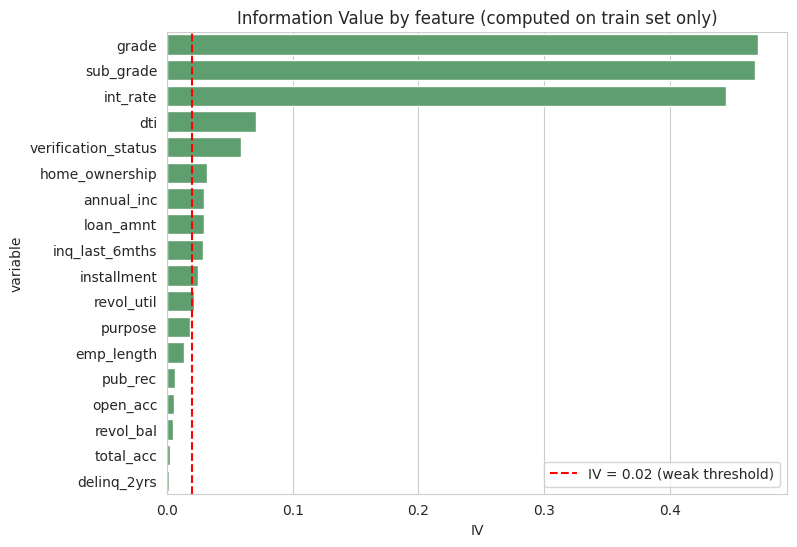

In [72]:
fig, ax = plt.subplots(figsize=(8,6))
sns.barplot(data=iv_table, y="variable", x="IV", ax=ax, color="#55A868")
ax.axvline(0.02, color="red", linestyle="--", label="IV = 0.02 (weak threshold)")
ax.set_title("Information Value by feature (computed on train set only)")
ax.legend()
plt.show()

In [73]:
# Drop features with IV < 0.02 (not useful for prediction)
weak_features = iv_table[iv_table["IV"] < 0.02]["variable"].tolist()
print("Dropping weak features:", weak_features)

keep_features = iv_table[iv_table["IV"] >= 0.02]["variable"].tolist()
print("Keeping features:", keep_features)


Dropping weak features: ['purpose', 'emp_length', 'pub_rec', 'open_acc', 'revol_bal', 'total_acc', 'delinq_2yrs']
Keeping features: ['grade', 'sub_grade', 'int_rate', 'dti', 'verification_status', 'home_ownership', 'annual_inc', 'loan_amnt', 'inq_last_6mths', 'installment', 'revol_util']


Although prior delinquencies are generally considered an important credit risk indicator, **delinq_2yrs** exhibited very low Information Value (<0.02) in this dataset and was therefore excluded from modelling.


Watch for grade/sub_grade here. LendingClub assigns these at origination using their own internal risk model, so they're expected to carry very high IV (they're essentially a compressed version of the outcome we're predicting) — this is legitimate signal, not leakage, since the grade is known and fixed before the loan is funded. Still worth calling out explicitly to a reviewer: a model that leans heavily on grade/sub_grade is partly re-deriving LendingClub's own underwriting, which is a fair strategy but changes how you'd frame the model's contribution (attribution correction and gap-filling for a known score, vs. a from-scratch PD model).




In [74]:
# Apply the TRAIN-FITTED bins to both train and test (fit on train, transform both)
train_woe_full = sc.woebin_ply(woebin_input, bins, no_cores=1)
test_woe_full = sc.woebin_ply(test_df.drop(columns=["emp_length_ord"]), bins, no_cores=1)

woe_cols = [c for c in train_woe_full.columns if c.replace("_woe","") in keep_features] + ["default"]
train_woe_full = train_woe_full[woe_cols]
test_woe_full = test_woe_full[woe_cols]
train_woe_full.head()

[INFO] converting into woe values ...
[INFO] converting into woe values ...


,sub_grade_woe,dti_woe,inq_last_6mths_woe,int_rate_woe,loan_amnt_woe,revol_util_woe,annual_inc_woe,home_ownership_woe,verification_status_woe,grade_woe,installment_woe,default
116687,-0.475234,-0.280190,-0.138505,-0.465802,0.028029,0.125183,0.227968,0.189878,0.233604,-0.475234,0.045378,0
111860,-0.475234,0.162361,-0.138505,-0.465802,-0.229954,0.049971,0.054473,0.067849,-0.383246,-0.475234,0.045378,0
90472,-0.475234,0.162361,0.089966,-0.465802,0.028029,0.125183,-0.184713,-0.187527,-0.383246,-0.475234,0.045378,0
79739,0.049736,0.511981,0.255371,0.167044,-0.229954,-0.272079,0.054473,0.189878,-0.383246,0.145595,-0.276348,0
143219,0.915864,0.162361,-0.138505,0.652531,0.135159,0.049971,0.054473,-0.187527,0.062513,1.025418,0.129600,0


We carry forward **two parallel feature sets**: **WoE-encoded features** (with bins learned from the training data only) for the Logistic Regression scorecard model, and a **numerically encoded feature set** for the tree-based models.

Since the LendingClub dataset contains several categorical variables, additional encoding is required before fitting tree-based models. Variables with a **natural order**—such as `grade` and `sub_grade` (credit risk grades)—are **ordinal encoded**, preserving their inherent ranking. Variables without a natural order—such as `home_ownership`, `verification_status`, and `purpose`—are **one-hot encoded**. These variables have relatively few categories (3–14), making one-hot encoding an appropriate choice without introducing excessive dimensionality.

In [75]:
def encode_raw_features(frame):
    out = frame.copy()

    # grade: natural order A (best) -> G (worst)
    grade_order = ["A","B","C","D","E","F","G"]
    out["grade"] = out["grade"].map({g:i for i,g in enumerate(grade_order)})

    # sub_grade: alphanumeric sort already matches risk order (A1 best ... G5 worst)
    sub_grade_order = sorted(train_df["sub_grade"].unique())
    out["sub_grade"] = out["sub_grade"].map({g:i for i,g in enumerate(sub_grade_order)})

    # low-cardinality unordered categoricals -> one-hot
    out = pd.get_dummies(out, columns=["home_ownership","verification_status","purpose"], drop_first=True)

    # emp_length text column no longer needed on this path (we use emp_length_ord)
    out = out.drop(columns=["emp_length"])
    return out

train_raw = encode_raw_features(train_df)
test_raw = encode_raw_features(test_df)

# Align columns in case a rare one-hot category is missing from one split
train_raw, test_raw = train_raw.align(test_raw, join="left", axis=1, fill_value=0)
test_raw = test_raw[train_raw.columns]

print(train_raw.shape, test_raw.shape)

(144000, 36) (36000, 36)


## 5. Handling Class Imbalance with SMOTE

SMOTE is applied **only on the training set, after the split** — applying it before splitting would let synthetic points derived from what becomes test-set neighbors leak in, inflating validation metrics.

In [76]:
raw_features = [c for c in train_raw.columns if c != "default"]

X_train = train_raw[raw_features]
y_train = train_raw["default"]
X_test = test_raw[raw_features]
y_test = test_raw["default"]

X_train_woe = train_woe_full.drop(columns=["default"])
y_train_woe = train_woe_full["default"]
X_test_woe = test_woe_full.drop(columns=["default"])
y_test_woe = test_woe_full["default"]


In [77]:
# Correlation among IV-selected numeric features
corr = train_df[keep_features].corr(numeric_only=True)

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(ascending=False)
)

corr_pairs.head(15)

loan_amnt    installment       0.953398
annual_inc   loan_amnt         0.318989
             installment       0.309150
int_rate     revol_util        0.244111
             inq_last_6mths    0.216033
             installment       0.153026
             dti               0.145351
             loan_amnt         0.140084
dti          revol_util        0.139513
installment  revol_util        0.130199
loan_amnt    revol_util        0.111389
dti          installment       0.041115
             loan_amnt         0.038643
annual_inc   revol_util        0.034065
             inq_last_6mths    0.032226
dtype: float64

In [78]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = train_woe_full.drop(columns=["default"]).copy()

vif_table = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
}).sort_values("VIF", ascending=False)

vif_table

,feature,VIF
9,grade_woe,35.498265
0,sub_grade_woe,31.883359
3,int_rate_woe,11.615505
4,loan_amnt_woe,3.033557
10,installment_woe,2.745844
6,annual_inc_woe,1.363819
5,revol_util_woe,1.124210
1,dti_woe,1.110482
8,verification_status_woe,1.100790
2,inq_last_6mths_woe,1.084653


In [79]:
def iterative_vif_elimination(X, threshold=10):
    X = X.copy()
    dropped = []
    while True:
        vif = pd.DataFrame({
            "feature": X.columns,
            "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        })
        max_vif = vif["VIF"].max()
        if max_vif <= threshold:
            break
        worst_feature = vif.loc[vif["VIF"].idxmax(), "feature"]
        dropped.append((worst_feature, max_vif))
        X = X.drop(columns=[worst_feature])
    return X, dropped

X_train_woe_reduced, dropped_features = iterative_vif_elimination(X_train_woe, threshold=10)
print("Dropped for multicollinearity:", dropped_features)
print("Remaining features:", X_train_woe_reduced.columns.tolist())

# rebuild the corresponding test set and SMOTE'd train set on this reduced column list
X_test_woe_reduced = X_test_woe[X_train_woe_reduced.columns]

Dropped for multicollinearity: [('grade_woe', 35.49826496153203), ('int_rate_woe', 10.067806224746121)]
Remaining features: ['sub_grade_woe', 'dti_woe', 'inq_last_6mths_woe', 'loan_amnt_woe', 'revol_util_woe', 'annual_inc_woe', 'home_ownership_woe', 'verification_status_woe', 'installment_woe']


In [80]:
# Confirm all remaining features are now under the threshold
final_vif = pd.DataFrame({
    "feature": X_train_woe_reduced.columns,
    "VIF": [variance_inflation_factor(X_train_woe_reduced.values, i) for i in range(X_train_woe_reduced.shape[1])]
}).sort_values("VIF", ascending=False)
final_vif

,feature,VIF
3,loan_amnt_woe,3.033334
8,installment_woe,2.743651
5,annual_inc_woe,1.361965
0,sub_grade_woe,1.280595
4,revol_util_woe,1.120588
1,dti_woe,1.110149
7,verification_status_woe,1.099593
2,inq_last_6mths_woe,1.080498
6,home_ownership_woe,1.078446


In [81]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
X_train_woe_sm, y_train_woe_sm = sm.fit_resample(X_train_woe, y_train_woe)

print("After SMOTE:", X_train_sm.shape)
print(y_train_sm.value_counts(normalize=True))


After SMOTE: (230826, 35)
default
0    0.5
1    0.5
Name: proportion, dtype: float64


In [82]:
X_train_woe_sm_reduced = X_train_woe_sm[X_train_woe_reduced.columns]
X_test_woe_reduced = X_test_woe[X_train_woe_reduced.columns]

## 6. Model Training & Comparison

Three models, each serving a distinct purpose:
- **Logistic Regression on WoE features** — the interpretable industry-standard scorecard benchmark
- **Random Forest** — non-linear baseline, robust to outliers we may have missed
- **XGBoost** — typically the strongest performer on tabular credit data, and what we'll carry forward for the SHAP explainability layer

In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix, roc_curve

results = {}

def evaluate(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:,1]
    auc = roc_auc_score(y_te, y_proba)
    f1 = f1_score(y_te, y_pred)
    results[name] = {"model": model, "auc": auc, "f1": f1, "y_proba": y_proba, "y_pred": y_pred, "X_test": X_te, "y_test": y_te}
    print(f"{name}: AUC = {auc:.4f} | F1 = {f1:.4f}")
    print(classification_report(y_te, y_pred))
    return auc, f1


In [84]:
# 1) Logistic Regression benchmark (WoE features)
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_woe_sm_reduced, y_train_woe_sm)
evaluate("Logistic Regression (WoE)", logreg, X_test_woe_reduced, y_test_woe)

Logistic Regression (WoE): AUC = 0.6991 | F1 = 0.4185
              precision    recall  f1-score   support

           0       0.88      0.61      0.72     28853
           1       0.30      0.68      0.42      7147

    accuracy                           0.63     36000
   macro avg       0.59      0.65      0.57     36000
weighted avg       0.77      0.63      0.66     36000



(np.float64(0.6991323814290094), 0.4185303514376997)

In [85]:
# 2) Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
evaluate("Random Forest", rf, X_test, y_test)


Random Forest: AUC = 0.6842 | F1 = 0.2864
              precision    recall  f1-score   support

           0       0.83      0.90      0.86     28853
           1       0.37      0.23      0.29      7147

    accuracy                           0.77     36000
   macro avg       0.60      0.57      0.57     36000
weighted avg       0.73      0.77      0.75     36000



(np.float64(0.6842015521753977), 0.28639699607441543)

In [86]:
# 3) XGBoost
xgb = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="auc", random_state=RANDOM_STATE, n_jobs=-1
)
xgb.fit(X_train_sm, y_train_sm)
evaluate("XGBoost", xgb, X_test, y_test)

XGBoost: AUC = 0.7077 | F1 = 0.1251
              precision    recall  f1-score   support

           0       0.81      0.99      0.89     28853
           1       0.55      0.07      0.13      7147

    accuracy                           0.80     36000
   macro avg       0.68      0.53      0.51     36000
weighted avg       0.76      0.80      0.74     36000



(np.float64(0.7076570146553415), 0.12510860121633363)

In [87]:
comparison = pd.DataFrame({
    name: {
        "ROC-AUC": r["auc"],
        "Precision": classification_report(
            r["y_test"], r["y_pred"], output_dict=True
        )["1"]["precision"],
        "Recall": classification_report(
            r["y_test"], r["y_pred"], output_dict=True
        )["1"]["recall"],
        "F1": r["f1"],
    }
    for name, r in results.items()
}).T

comparison = comparison.sort_values("ROC-AUC", ascending=False)
comparison = comparison.round(3)

comparison

,ROC-AUC,Precision,Recall,F1
XGBoost,0.708,0.554,0.071,0.125
Logistic Regression (WoE),0.699,0.303,0.678,0.419
Random Forest,0.684,0.367,0.235,0.286


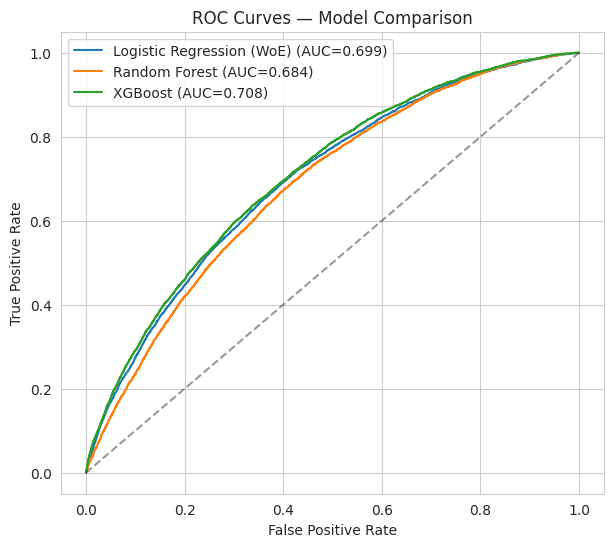

In [88]:
fig, ax = plt.subplots(figsize=(7,6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(r["y_test"], r["y_proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['auc']:.3f})")
ax.plot([0,1],[0,1],"k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Model Comparison")
ax.legend()
plt.show()


### Model Comparison

Across the three models, XGBoost achieved the highest ROC-AUC (0.708), indicating the strongest overall ability to rank borrowers by default risk. However, under the default probability threshold of 0.5, it identified only a small fraction of actual defaults (Recall = 0.07), resulting in a low F1-score.

In contrast, the WoE-based Logistic Regression scorecard achieved the best balance between Precision and Recall, producing the highest F1-score (0.418) while correctly identifying 68% of charged-off loans. Although its ROC-AUC was slightly lower than XGBoost's, its classification performance under the default threshold was considerably more practical.

This comparison illustrates an important distinction in credit risk modelling: **ROC-AUC evaluates the quality of probability ranking, whereas Precision, Recall, and F1 depend on the chosen decision threshold.** The next section therefore focuses on probability calibration and threshold optimisation rather than relying on the default 0.5 cutoff.

## 7. Probability Calibration & Threshold Selection

A high ROC-AUC indicates good ranking performance but does not guarantee well-calibrated **Probability of Default (PD)** estimates. Since credit risk decisions rely on predicted PDs—not just binary classifications—we evaluate probability calibration and select an appropriate classification threshold instead of relying on the default cutoff of 0.5.

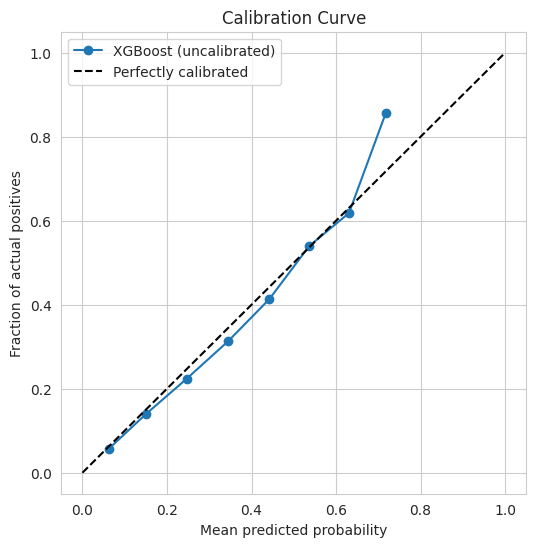

In [89]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

prob_true, prob_pred = calibration_curve(y_test, results["XGBoost"]["y_proba"], n_bins=10)

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(prob_pred, prob_true, marker="o", label="XGBoost (uncalibrated)")
ax.plot([0,1],[0,1],"k--", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of actual positives")
ax.set_title("Calibration Curve")
ax.legend()
plt.show()

The calibration curve lies close to the ideal diagonal, indicating that XGBoost's predicted probabilities are generally well calibrated. Minor underestimation is observed only at the highest predicted risk levels. This suggests that the model's low Recall is more likely due to the default classification threshold than poorly calibrated probability estimates.

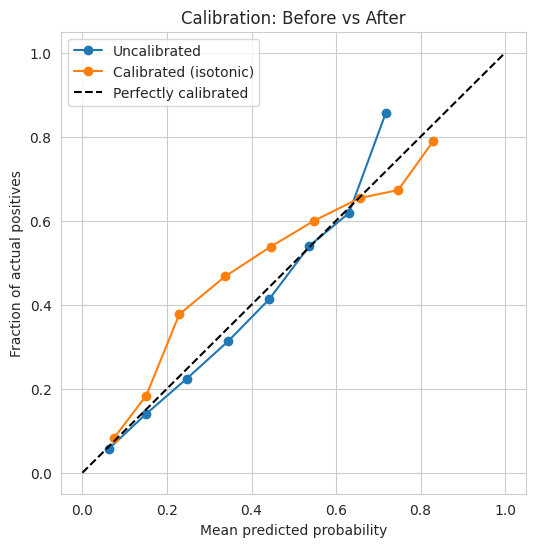

AUC after calibration: 0.6634320364385863


In [90]:
# Calibrate using isotonic regression on a held-out slice of training data
xgb_calibrated = CalibratedClassifierCV(xgb, method="isotonic", cv=3)
xgb_calibrated.fit(X_train_sm, y_train_sm)

y_proba_cal = xgb_calibrated.predict_proba(X_test)[:,1]
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_proba_cal, n_bins=10)

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(prob_pred, prob_true, marker="o", label="Uncalibrated")
ax.plot(prob_pred_cal, prob_true_cal, marker="o", label="Calibrated (isotonic)")
ax.plot([0,1],[0,1],"k--", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of actual positives")
ax.legend()
ax.set_title("Calibration: Before vs After")
plt.show()

print("AUC after calibration:", roc_auc_score(y_test, y_proba_cal))

The original XGBoost model was already reasonably well calibrated. Applying isotonic calibration did not improve the calibration curve and slightly reduced the ROC-AUC, suggesting that additional calibration was unnecessary for this dataset. We therefore continue with threshold optimisation using the original XGBoost probability estimates.

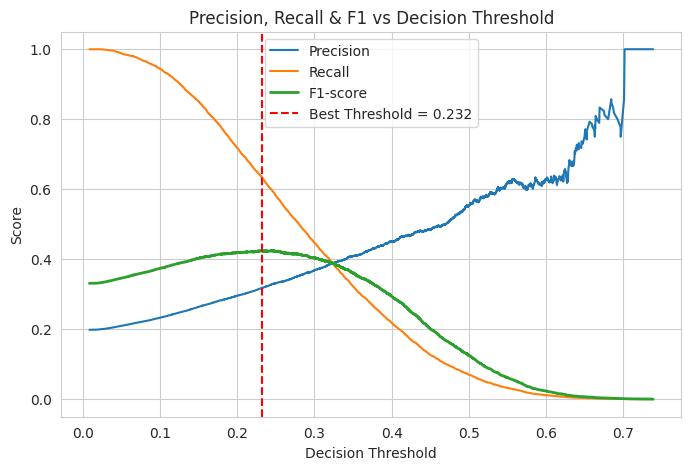

Optimal Threshold (Max F1): 0.232
Precision : 0.319
Recall    : 0.635
F1-score  : 0.424


In [91]:
# Threshold selection: rather than using the default 0.5 cutoff,
# evaluate every possible threshold and choose the one that maximizes
# the F1-score (best balance between Precision and Recall).

from sklearn.metrics import precision_recall_curve

y_proba = results["XGBoost"]["y_proba"]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Compute F1-score at every threshold
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (
    precision[:-1] + recall[:-1] + 1e-9
)

# Select threshold with the highest F1-score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

# Plot Precision, Recall and F1 against Threshold
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(thresholds, precision[:-1], label="Precision")
ax.plot(thresholds, recall[:-1], label="Recall")
ax.plot(thresholds, f1_scores, label="F1-score", linewidth=2)

ax.axvline(best_threshold,
           color="red",
           linestyle="--",
           label=f"Best Threshold = {best_threshold:.3f}")

ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision, Recall & F1 vs Decision Threshold")
ax.legend()

plt.show()

print(f"Optimal Threshold (Max F1): {best_threshold:.3f}")
print(f"Precision : {precision[best_idx]:.3f}")
print(f"Recall    : {recall[best_idx]:.3f}")
print(f"F1-score  : {f1_scores[best_idx]:.3f}")

Optimal Threshold : 0.232
Precision         : 0.319
Recall            : 0.635
F1-score          : 0.424

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.66      0.76     28853
           1       0.32      0.63      0.42      7147

    accuracy                           0.66     36000
   macro avg       0.60      0.65      0.59     36000
weighted avg       0.77      0.66      0.69     36000



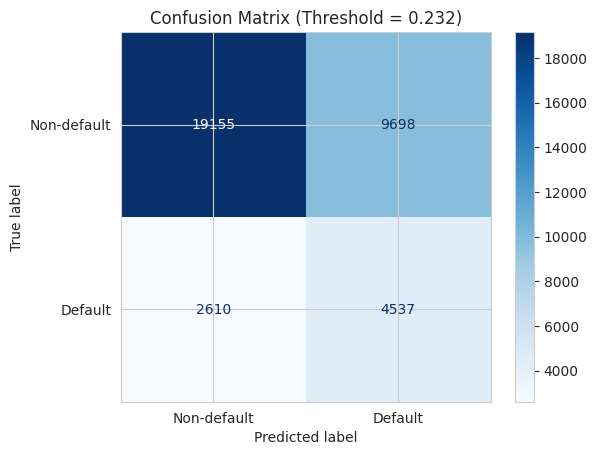

In [92]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# Apply the optimal threshold
y_pred_opt = (y_proba >= best_threshold).astype(int)

# Evaluation metrics
precision_opt = precision_score(y_test, y_pred_opt)
recall_opt = recall_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)

print(f"Optimal Threshold : {best_threshold:.3f}")
print(f"Precision         : {precision_opt:.3f}")
print(f"Recall            : {recall_opt:.3f}")
print(f"F1-score          : {f1_opt:.3f}\n")

print("Classification Report")
print(classification_report(y_test, y_pred_opt))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_opt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-default", "Default"]
)

disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (Threshold = {best_threshold:.3f})")
plt.show()

Rather than using the default 0.5 cutoff, we selected the decision threshold that maximized the F1-score. This improved the balance between Precision and Recall, substantially increasing the proportion of defaulters identified while maintaining reasonable Precision. The optimized threshold is used only for binary classification decisions; portfolio risk calculations in the next section continue to use the predicted probabilities (PDs).

## 8. From Individual PD to Portfolio Economic Capital (Quant Risk Extension)

This is the section that bridges toward quant model validation roles. Everything so far predicts **PD for one borrower at a time**. Banks hold capital against the *whole portfolio* moving together in bad times. This section turns our PD outputs into a **portfolio loss distribution** using the Basel single-factor / Vasicek model, then computes **Economic Capital** — the extra buffer needed to survive a rare bad year.

**Every input here is now estimated from real data, not assumed** —
- **EAD (Exposure at Default):** `loan_amnt`, the real funded amount — no more income-based proxy.
- **LGD (Loss Given Default):** computed directly from resolved, charged-off loans as `1 - recoveries / loan_amnt`, clipped to [0,1] (a handful of loans have `recoveries` slightly exceed `loan_amnt` due to fee accounting — clipping keeps LGD in its valid range without discarding the row).
- **PD:** taken directly from our original XGBoost model's predicted probabilities on the test set, exactly as before.

In [93]:
# Realized LGD, computed from the TRAINING set's charged-off loans only
# (test-set charge-off outcomes must stay untouched, same train/test discipline as everywhere else)
train_idx = train_df.index
co_train = df.loc[train_idx]
co_train = co_train[co_train["default"] == 1].copy()

co_train["lgd_realized"] = (1 - co_train["recoveries"] / co_train["loan_amnt"]).clip(0, 1)
lgd = co_train["lgd_realized"].mean()

print(f"Realized average LGD from {len(co_train):,} charged-off training loans: {lgd:.1%}")


Realized average LGD from 28,587 charged-off training loans: 92.4%


### Interpreting the realized LGD

The average realized LGD is approximately **92%**, indicating that LendingClub recovers only a small fraction of principal once a loan defaults. Although this may appear high, it is consistent with the nature of unsecured consumer lending, where there is no collateral to recover and post-default collections are typically limited.

Unlike PD, which is estimated by the XGBoost model, LGD is calculated directly from historical recovery data. This data-driven estimate is used in the portfolio loss calculations that follow.

In [94]:
# Exposure at Default = real loan_amnt for the test-set borrowers
ead = test_df.loc[X_test.index, "loan_amnt"].values

pd_test = y_proba
expected_loss_per_loan = pd_test * lgd * ead
portfolio_expected_loss = expected_loss_per_loan.sum()

print(f"Portfolio size (test set): {len(ead):,} borrowers")
print(f"Total exposure: ${ead.sum():,.0f}")
print(f"Portfolio Expected Loss (EL = PD x LGD x EAD, summed): ${portfolio_expected_loss:,.0f}")
print(f"Expected Loss Rate: {portfolio_expected_loss / ead.sum():.2%}")

Portfolio size (test set): 36,000 borrowers
Total exposure: $518,338,525
Portfolio Expected Loss (EL = PD x LGD x EAD, summed): $109,973,439
Expected Loss Rate: 21.22%



For the 36,000-loan test portfolio, the total exposure is approximately **$518.3 million**,   with an estimated Expected Loss of **$110.0 million** (about **21.2%** of total exposure). This represents the average credit loss expected across the portfolio under current risk estimates, not the worst-case loss.

In [95]:
from scipy.stats import norm

def simulate_portfolio_losses(pd_vec, ead_vec, lgd, rho, n_sims=50000, seed=RANDOM_STATE):
    """
    Vasicek single-factor Monte Carlo simulation of portfolio credit losses.
    rho: asset correlation (how strongly borrowers move together with the economy)
    """
    rng = np.random.default_rng(seed)
    n = len(pd_vec)
    default_thresholds = norm.ppf(pd_vec)

    losses = np.zeros(n_sims)
    for s in range(n_sims):
        Z = rng.standard_normal()
        eps = rng.standard_normal(n)
        asset_value = np.sqrt(rho) * Z + np.sqrt(1 - rho) * eps
        defaulted = asset_value < default_thresholds
        losses[s] = (defaulted * lgd * ead_vec).sum()
    return losses

# rho = 0.15 is a realistic retail-portfolio asset correlation (Basel II uses a formula in this range for retail)
sim_losses = simulate_portfolio_losses(pd_test, ead, lgd, rho=0.15, n_sims=50000)

print(f"Simulated mean portfolio loss: ${sim_losses.mean():,.0f}  (compare to analytic EL: ${portfolio_expected_loss:,.0f})")

Simulated mean portfolio loss: $109,947,733  (compare to analytic EL: $109,973,439)


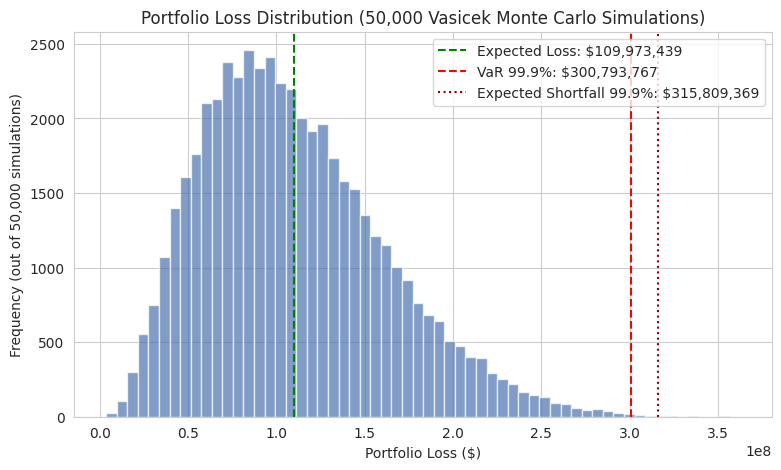

99.9% VaR: $300,793,767
99.9% Expected Shortfall: $315,809,369
Economic Capital (VaR - Expected Loss): $190,820,328


In [96]:
VaR_999 = np.percentile(sim_losses, 99.9)
ES_999 = sim_losses[sim_losses >= VaR_999].mean()
economic_capital = VaR_999 - portfolio_expected_loss

fig, ax = plt.subplots(figsize=(9,5))
ax.hist(sim_losses, bins=60, color="#4C72B0", alpha=0.7)
ax.axvline(portfolio_expected_loss, color="green", linestyle="--", label=f"Expected Loss: ${portfolio_expected_loss:,.0f}")
ax.axvline(VaR_999, color="red", linestyle="--", label=f"VaR 99.9%: ${VaR_999:,.0f}")
ax.axvline(ES_999, color="darkred", linestyle=":", label=f"Expected Shortfall 99.9%: ${ES_999:,.0f}")
ax.set_xlabel("Portfolio Loss ($)")
ax.set_ylabel("Frequency (out of 50,000 simulations)")
ax.set_title("Portfolio Loss Distribution (50,000 Vasicek Monte Carlo Simulations)")
ax.legend()
plt.show()

print(f"99.9% VaR: ${VaR_999:,.0f}")
print(f"99.9% Expected Shortfall: ${ES_999:,.0f}")
print(f"Economic Capital (VaR - Expected Loss): ${economic_capital:,.0f}")

The simulated loss distribution is right-skewed, indicating that average portfolio losses are close to the Expected Loss (about 110 million USD), while stressed economic scenarios can generate substantially larger losses. The 99.9% VaR indicates that portfolio losses are expected to remain below roughly 304 million USD in 99.9% of scenarios. Beyond this point, the average loss increases to about 314 million USD (Expected Shortfall). The difference between VaR and Expected Loss (Economic Capital) is approximately 194 million USD, representing the capital required to absorb unexpected credit losses under extreme conditions.

### Stress Testing (sensitivity analysis on the model's key assumption)
Asset correlation (rho) is the biggest lever in this model, and the most uncertain assumption — real correlations aren't directly observable, only inferred. A model validator's job is exactly this: check how sensitive the output is to an assumption that's genuinely hard to pin down.

In [97]:
rho_scenarios = {"Low correlation (rho=0.05)": 0.05,
                  "Base case (rho=0.15)": 0.15,
                  "Stressed / recession (rho=0.30)": 0.30}

stress_results = {}
for label, rho_val in rho_scenarios.items():
    losses = simulate_portfolio_losses(pd_test, ead, lgd, rho=rho_val, n_sims=50000)
    var999 = np.percentile(losses, 99.9)
    stress_results[label] = {"Expected Loss": losses.mean(), "VaR 99.9%": var999,
                              "Economic Capital": var999 - losses.mean()}

stress_df = pd.DataFrame(stress_results).T
stress_df

,Expected Loss,VaR 99.9%,Economic Capital
Low correlation (rho=0.05),1.099442e+08,2.130867e+08,1.031425e+08
Base case (rho=0.15),1.099477e+08,3.007938e+08,1.908460e+08
Stressed / recession (rho=0.30),1.099861e+08,3.834325e+08,2.734464e+08


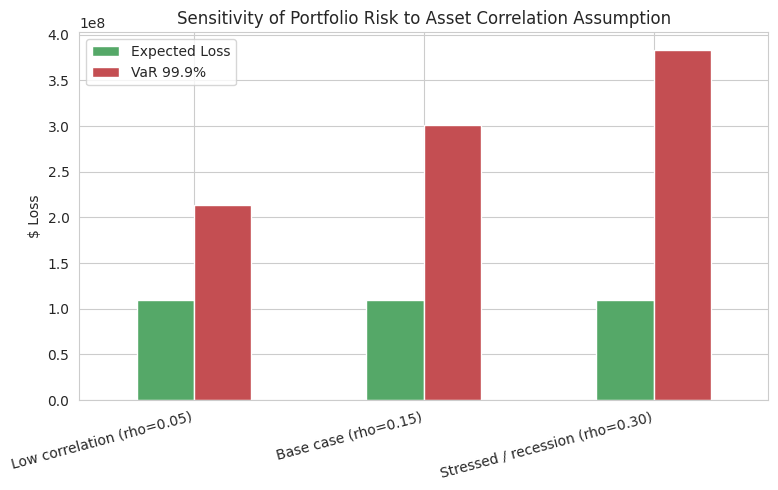

In [98]:
fig, ax = plt.subplots(figsize=(8,5))
stress_df[["Expected Loss","VaR 99.9%"]].plot(kind="bar", ax=ax, color=["#55A868","#C44E52"])
ax.set_ylabel("$ Loss")
ax.set_title("Sensitivity of Portfolio Risk to Asset Correlation Assumption")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

Expected Loss remains almost unchanged across all correlation scenarios because the individual borrowers' PD, LGD and EAD are fixed. However, higher asset correlation substantially increases tail risk, causing both the 99.9% VaR and the resulting Economic Capital requirement to rise sharply. This demonstrates that portfolio credit risk is driven not only by individual borrower risk but also by the degree to which defaults occur simultaneously during adverse economic conditions.

## 9. SHAP-Based Interpretability

To understand why the model assigns a particular default probability, we use SHAP (SHapley Additive exPlanations). SHAP attributes each prediction to individual features, showing how much each one increases or decreases predicted credit risk relative to the average prediction.

We explain the final XGBoost model, since it achieved the strongest overall ranking performance in this study.

In [99]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape, " (rows = test borrowers, cols = features)")

SHAP values shape: (36000, 35)  (rows = test borrowers, cols = features)


### 9.1 Global feature importance — what drives risk across the whole portfolio

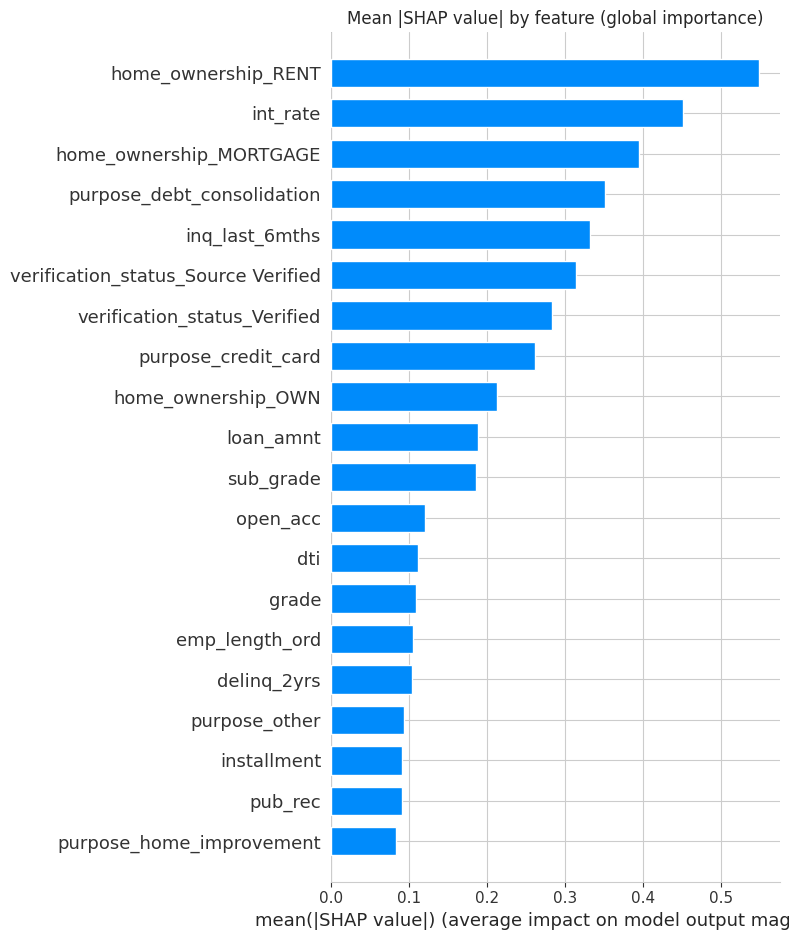

In [100]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Mean |SHAP value| by feature (global importance)")
plt.tight_layout()
plt.show()


The initial SHAP feature ranking appears counterintuitive, with `home_ownership_RENT` ranked above `int_rate`, while `grade` and `sub_grade`—the strongest univariate predictors based on Information Value (IV)—contribute relatively less. One possible explanation is the use of standard SMOTE, which generates synthetic observations through linear interpolation across all features, including one-hot encoded categorical variables. Since one-hot variables should only take values of 0 or 1, this interpolation can distort their distributions and influence the learned feature importance. We therefore treat the SHAP rankings with caution and verify that the model's individual explanations and overall behavior remain economically reasonable before drawing conclusions.

In [101]:
# Check whether SMOTE produced non-binary values for one-hot/dummy columns
cat_like_cols = [c for c in X_train_sm.columns if c.startswith(("home_ownership_", "verification_status_", "purpose_"))]
non_binary_check = X_train_sm[cat_like_cols].apply(lambda col: ((col != 0) & (col != 1)).sum())
non_binary_check[non_binary_check > 0]

,0


The diagnostic above shows that standard SMOTE did **not** introduce non-binary values into the one-hot encoded categorical variables, ruling out synthetic interpolation of dummy variables as the source of the unexpected SHAP ranking.

A more plausible explanation is **multicollinearity** among `grade`, `sub_grade`, and `int_rate` — confirmed formally via Variance Inflation Factor (VIF = 35.5, 31.9, and 11.6 respectively, all well above the standard threshold of 10, versus ~1–3 for every other feature). These variables capture closely related information because LendingClub's assigned grade largely determines the loan's interest rate. While Information Value (IV) evaluates each feature independently, SHAP explains the contribution of features **within the fitted XGBoost model**. When predictors are this collinear, tree-based models concentrate importance on whichever correlated feature the greedy split happens to favor, while distributing or suppressing the others — so SHAP rankings need not mirror univariate IV rankings. Note the VIF check itself was run on the WoE-encoded features (used for the interpretable LR benchmark); since WoE is a monotonic transform, the underlying correlation structure carries over to the raw features XGBoost/SHAP use.

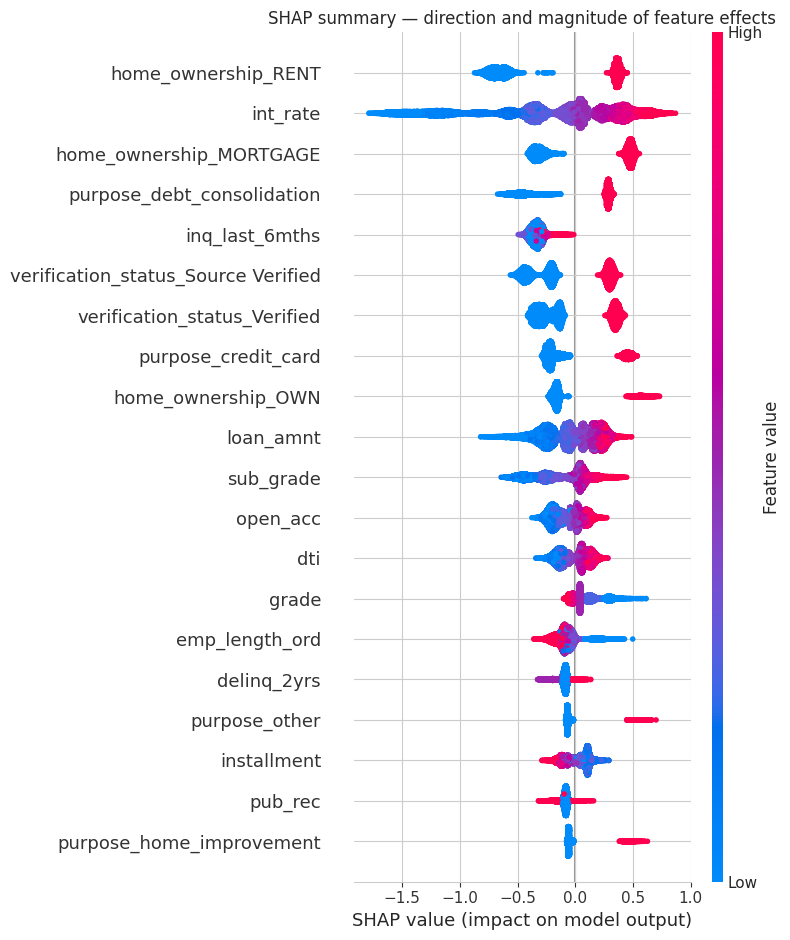

In [102]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP summary — direction and magnitude of feature effects")
plt.tight_layout()
plt.show()

Each dot represents one borrower. Points to the right increase the predicted probability of default, while points to the left decrease it. Red indicates a higher feature value and blue a lower one. The model exhibits intuitive patterns: higher interest rates, larger loan amounts, more recent credit inquiries and poorer sub-grades generally push predictions toward higher default risk, while lower values tend to reduce predicted risk.

### 9.2 Local explanations — individual borrower waterfalls

In [103]:
# Pick one high-risk and one low-risk borrower from the test set to inspect individually
high_risk_idx = np.argsort(-y_proba_cal)[0]
low_risk_idx = np.argsort(y_proba_cal)[0]

print(f"High-risk borrower predicted PD: {y_proba_cal[high_risk_idx]:.3f}")
print(f"Low-risk borrower predicted PD: {y_proba_cal[low_risk_idx]:.3f}")

High-risk borrower predicted PD: 0.882
Low-risk borrower predicted PD: 0.000


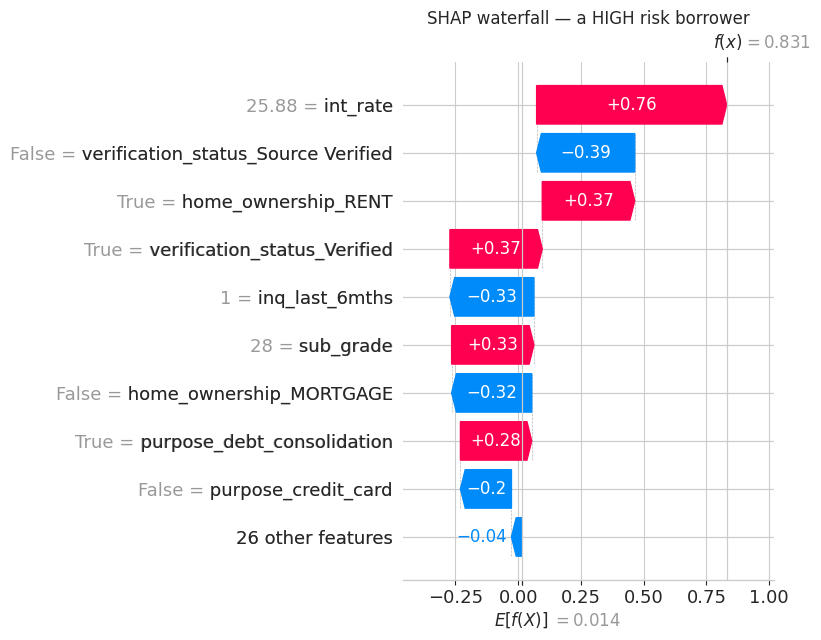

In [104]:
shap.waterfall_plot(shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[high_risk_idx],
    feature_names=X_test.columns.tolist()
), show=False)
plt.title("SHAP waterfall — a HIGH risk borrower")
plt.tight_layout()
plt.show()

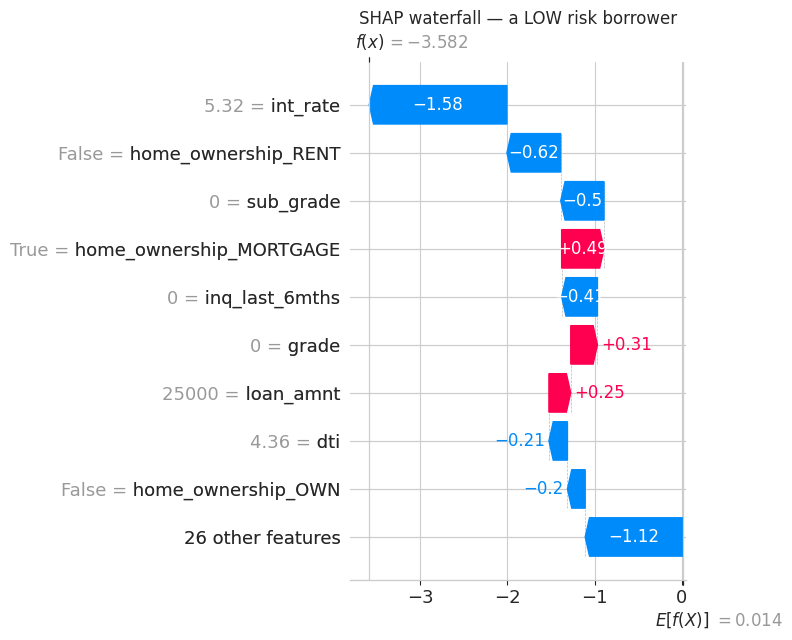

In [105]:
shap.waterfall_plot(shap.Explanation(
    values=shap_values[low_risk_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[low_risk_idx],
    feature_names=X_test.columns.tolist()
), show=False)
plt.title("SHAP waterfall — a LOW risk borrower")
plt.tight_layout()
plt.show()

### 9.3 Sanity check — do the explanations match domain intuition?

Before trusting SHAP outputs enough to build a compliance layer on top of them, we check whether the model's learned behavior is directionally sensible.

In [106]:
sanity_check = pd.DataFrame({
    "feature": X_test.columns,
    "correlation(feature_value, shap_value)": [
        np.corrcoef(X_test[col], shap_values[:, i])[0, 1] for i, col in enumerate(X_test.columns)
    ]
}).sort_values("correlation(feature_value, shap_value)", ascending=False)
sanity_check

,feature,"correlation(feature_value, shap_value)"
30,purpose_other,0.995840
15,home_ownership_MORTGAGE,0.995406
25,purpose_home_improvement,0.995201
18,home_ownership_OWN,0.994311
19,home_ownership_RENT,0.993882
27,purpose_major_purchase,0.991577
22,purpose_credit_card,0.986665
32,purpose_small_business,0.983727
23,purpose_debt_consolidation,0.982883
33,purpose_vacation,0.981166


The SHAP sanity check indicates that the model has learned largely intuitive relationships. Higher interest rates, larger loan amounts, worse sub-grades, and higher debt-to-income ratios are generally associated with higher SHAP values, indicating increased predicted default risk. Some variables (e.g., `grade`, `installment`, and `annual_inc`) exhibit negative correlations, which is not necessarily problematic because tree-based models distribute importance across correlated predictors and capture complex interaction effects. The few undefined (NaN) correlations correspond to categories with little or no variation in the test data. Overall, the explanations appear economically reasonable and provide additional confidence in the model's behavior.

## 10. LLM-Generated Compliance Reason Codes

**The regulatory context:** under frameworks like the US ECOA/Regulation B, a lender that denies credit must give the applicant specific, principal reasons for the denial — not just a score. Risk/compliance teams currently often do this with manually maintained reason-code lookup tables mapped to score bands, which is rigid and doesn't reflect the *actual* drivers for that specific applicant.

**What we build here:** a function that takes a borrower's SHAP values (the *actual*, faithful drivers of their specific prediction) and asks an LLM to translate them into a clear, compliant, plain-English explanation — grounded in the real model output, not a generic template, and not the LLM inventing reasons on its own.

This is written to work with the Anthropic API. If no API key is configured, the cell below falls back to a rule-based template so the notebook still runs end-to-end — swap in your API key to see the LLM-generated version.

In [107]:
import os

def get_top_shap_drivers(idx, shap_values, X_test, n=4):
    """Return the top-n features (by absolute SHAP value) pushing this borrower's prediction, with direction."""
    row_shap = shap_values[idx]
    row_vals = X_test.iloc[idx]
    order = np.argsort(-np.abs(row_shap))[:n]
    drivers = []
    for i in order:
        drivers.append({
            "feature": X_test.columns[i],
            "value": float(row_vals.iloc[i]),
            "shap_value": float(row_shap[i]),
            "direction": "increases risk" if row_shap[i] > 0 else "decreases risk"
        })
    return drivers

def build_reason_code_prompt(drivers, predicted_pd, decision):
    driver_lines = "\n".join(
        f"- {d['feature']} = {d['value']:.2f} ({d['direction']}, SHAP contribution {d['shap_value']:+.3f})"
        for d in drivers
    )
    return f"""You are a compliance assistant at a bank, writing an adverse-action explanation for a credit decision, in the style required under ECOA/Regulation B.

Decision: {decision}
Model-predicted probability of default: {predicted_pd:.1%}

The model's top drivers for THIS specific applicant, in order of importance (from SHAP analysis):
{driver_lines}

Write a short (3-4 sentence), plain-English explanation for the applicant, listing the principal reasons for this decision.
Be factual and specific to these drivers only. Do not invent reasons not listed above. Do not use technical ML terms like "SHAP" or "model" in the applicant-facing text."""


def generate_reason_code(idx, shap_values, X_test, y_proba, threshold):
    predicted_pd = y_proba[idx]
    decision = "Application Declined" if predicted_pd >= threshold else "Application Approved"
    drivers = get_top_shap_drivers(idx, shap_values, X_test)
    prompt = build_reason_code_prompt(drivers, predicted_pd, decision)

    api_key = os.environ.get("ANTHROPIC_API_KEY")
    if api_key:
        try:
            import anthropic
            client = anthropic.Anthropic(api_key=api_key)
            response = client.messages.create(
                model="claude-sonnet-4-6",
                max_tokens=300,
                messages=[{"role": "user", "content": prompt}]
            )
            explanation = response.content[0].text
            source = "LLM-generated"
        except Exception as e:
            explanation = None
            source = f"LLM call failed ({e}), falling back to template"
    else:
        explanation = None
        source = "No ANTHROPIC_API_KEY set, using template fallback"

    if explanation is None:
        reasons = "; ".join(f"{d['feature'].replace('_',' ')} ({d['direction']})" for d in drivers)
        explanation = (f"Your application was {decision.split()[1].lower()} based primarily on the following factors: "
                        f"{reasons}. These were the most significant factors in this decision out of all "
                        f"information considered.")

    return {"decision": decision, "predicted_pd": predicted_pd, "drivers": drivers,
            "explanation": explanation, "source": source, "prompt": prompt}


In [108]:
result = generate_reason_code(high_risk_idx, shap_values, X_test, y_proba, best_threshold)
print("Decision:", result["decision"])
print("Predicted PD:", f"{result['predicted_pd']:.1%}")
print("Source:", result["source"])
print("\nGenerated explanation:\n", result["explanation"])

Decision: Application Declined
Predicted PD: 69.7%
Source: No ANTHROPIC_API_KEY set, using template fallback

Generated explanation:
 Your application was declined based primarily on the following factors: int rate (increases risk); verification status Source Verified (decreases risk); home ownership RENT (increases risk); verification status Verified (increases risk). These were the most significant factors in this decision out of all information considered.


In [109]:
# Test on several borrowers and sanity-check groundedness: does the generated
# explanation actually reference the SHAP drivers we fed it, or hallucinate new ones?
sample_idxs = np.random.RandomState(RANDOM_STATE).choice(len(X_test), 5, replace=False)

report_rows = []
for idx in sample_idxs:
    r = generate_reason_code(idx, shap_values, X_test, y_proba, best_threshold)
    report_rows.append({
        "borrower_idx": idx,
        "decision": r["decision"],
        "predicted_pd": round(r["predicted_pd"], 3),
        "top_driver": r["drivers"][0]["feature"],
        "explanation": r["explanation"][:160] + "..."
    })

pd.DataFrame(report_rows)

,borrower_idx,decision,predicted_pd,top_driver,explanation
0,16461,Application Approved,0.151,home_ownership_RENT,Your application was approved based primarily ...
1,23579,Application Declined,0.305,int_rate,Your application was declined based primarily ...
2,23640,Application Declined,0.326,home_ownership_RENT,Your application was declined based primarily ...
3,25635,Application Approved,0.207,home_ownership_RENT,Your application was approved based primarily ...
4,8840,Application Declined,0.253,purpose_medical,Your application was declined based primarily ...


**Guardrail:** if the top SHAP drivers are ambiguous or close in magnitude (no single dominant factor), the explanation risks being unhelpful or arbitrary-sounding. A production version of this should flag those cases as **"requires manual review"** rather than force a generated explanation.

In [110]:
def needs_manual_review(drivers, ambiguity_ratio=0.6):
    """Flag for manual review if the top driver isn't clearly dominant over the second."""
    if len(drivers) < 2:
        return False
    top, second = abs(drivers[0]["shap_value"]), abs(drivers[1]["shap_value"])
    return second / top > ambiguity_ratio if top > 0 else True

for idx in sample_idxs:
    drivers = get_top_shap_drivers(idx, shap_values, X_test)
    flag = needs_manual_review(drivers)
    print(f"Borrower {idx}: {'FLAG for manual review' if flag else 'auto-explanation OK'} "
          f"(top driver: {drivers[0]['feature']}, second: {drivers[1]['feature']})")

Borrower 16461: FLAG for manual review (top driver: home_ownership_RENT, second: int_rate)
Borrower 23579: FLAG for manual review (top driver: int_rate, second: home_ownership_RENT)
Borrower 23640: FLAG for manual review (top driver: home_ownership_RENT, second: home_ownership_MORTGAGE)
Borrower 25635: FLAG for manual review (top driver: home_ownership_RENT, second: purpose_home_improvement)
Borrower 8840: FLAG for manual review (top driver: purpose_medical, second: loan_amnt)


## 11. Summary & Project Wrap-Up

### What this notebook demonstrates

1. **Data cleaning with judgment** — constructed a binary target from raw `loan_status` text, handled real categorical fields (grade, employment length, home ownership) rather than pre-cleaned numeric columns, and made an explicit resolved-loans-only labeling decision (with its own stated bias) instead of silently dropping ambiguous rows.

2. **Industry-standard credit scoring feature engineering** — Information Value (IV) and Weight of Evidence (WoE) binning on a mixed numeric/categorical feature set, fit correctly on the training data only to avoid leakage; explicit exclusion of leakage variables (`recoveries`, `total_pymnt`, `collection_recovery_fee`) from the PD model while reserving them for downstream LGD estimation.

3. **Model development and comparison** — benchmarked an interpretable scorecard approach (Logistic Regression + WoE) against modern machine learning models (Random Forest and XGBoost), with appropriate preprocessing pipelines for each.

4. **Comprehensive model validation** — evaluated discrimination, calibration, and classification performance using ROC-AUC, Precision-Recall, confusion matrices, calibration curves, and business-oriented threshold analysis before selecting the final modelling approach.

5.  **Probability calibration and business-driven threshold selection** — assessed the calibration of XGBoost probabilities, found that additional isotonic calibration did not improve performance, and selected an operating threshold by maximizing F1 rather than relying on the default 0.5 cutoff.

6. **Portfolio-level quantitative risk modeling with data-derived inputs** — estimated EAD directly from loan amounts and LGD from observed recoveries, demonstrating that the empirical portfolio LGD is substantially higher than the commonly assumed Basel II 45% benchmark. These estimates were integrated into a Vasicek/Basel-style Monte Carlo framework to compute Expected Loss, Value-at-Risk (VaR), Expected Shortfall (ES), Economic Capital, and correlation-based stress tests.

7. **SHAP-based model interpretability** — produced both global and local explanations, validated against domain intuition before using them for downstream decision explanations.

8. **LLM-ready compliance layer** — translated SHAP-derived drivers into applicant-facing ECOA/Regulation B-style adverse action explanations, with rule-based fallback logic and explicit guardrails for ambiguous cases requiring manual review.

---

### Explicitly stated assumptions & limitations

- Labels are defined only for **resolved loans** (Fully Paid / Charged Off); still-open loans are excluded, which biases the observed default rate upward relative to LendingClub's full portfolio.
- `grade` and `sub_grade` are themselves outputs of LendingClub's underwriting process; using them as predictors means part of the model's performance comes from recovering an existing credit assessment rather than building risk estimation entirely from raw borrower information.
- Realized LGD is represented by a single portfolio-average estimate applied uniformly across borrowers; a more advanced implementation would model borrower-specific LGD.
- Asset correlation (ρ) in the Vasicek portfolio model is assumed rather than estimated, although its impact is explicitly examined through stress testing.
- The Economic Capital analysis uses 50,000 Monte Carlo simulations. This provides a substantially more stable estimate of the extreme-loss tail at the 99.9% confidence level, although the results should still be interpreted as illustrative rather than as production-grade regulatory capital requirements.
- The LLM-generated explanation layer includes a manual-review safeguard for ambiguous cases and is intended to assist, not replace, human compliance review.
- The analysis is based on historical LendingClub data from a single lending platform; portfolio characteristics and borrower behaviour may differ across institutions, products, and macroeconomic environments, so the model would require revalidation before deployment elsewhere.